# High-Dimensional Latent Geodesics — and an honest look at the solver

Interpolating in the latent space of a generative model is a geodesic problem. A
straight line between two latent codes cuts through the empty region between data
clusters and decodes to blurry, superimposed images; a geodesic under a
*data-aware* metric stays where the data lives and decodes to valid samples. This
is exactly the setting of recent energy-based-model geometry
([Syrota et al., 2025](https://arxiv.org/abs/2505.18230)), who derive a conformal
Riemannian metric from a trained EBM and interpolate *rotated characters* along it.

HAM solves the full geodesic **boundary-value problem** for *any* Finsler metric
with the `AVBDSolver`, with no per-problem training. That generality has a price,
and this notebook is unusually candid about it. We

1. train a genuine autoencoder on rotated shapes and build the EBM-style metric,
2. show linear interpolation fails,
3. **diagnose, with controlled experiments, exactly why the solver struggles on
   long, high-dimensional geodesics** — and show the failure is *not* about
   dimension,
4. fix it with numerical continuation + a new second-order solver
   (`GaussNewtonGeodesic`), and recover clean long-range rotations,
5. state the limitations plainly.

The geometry is metric-first: a `FinslerMetric` is one scalar field $F(x,v)$, and
the energy $\mathcal{E}[\gamma]=\int \tfrac12 F^2\,dt$, geodesic spray, and
curvature follow by autodiff. Only the metric and data change between this 256-D
problem and the 2-D demos in the suite.

In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

from ham.geometry import EuclideanSpace, Riemannian
from ham.nn.kde import GaussianKDEEnergy
from ham.solvers import AVBDSolver, GaussNewtonGeodesic, solve_continuation
from ham.vis.style import use_ham_style, PALETTE

use_ham_style()
jax.config.update("jax_enable_x64", False)
np.random.seed(0)
IMG = 28
PIX = IMG * IMG
LAT = 64
print("ambient pixel dim =", PIX, "| latent dim =", LAT)

ambient pixel dim = 784 | latent dim = 64


## 1. A genuine learned latent space

To keep the demo self-contained (no downloads) but *honest* (a real trained
encoder, not a hand-built embedding), we render an **asymmetric shape** — a bar
with an off-centre dot, so its orientation is unambiguous — at 144 rotation
angles, and train a small MLP autoencoder $\mathbb{R}^{784}\!\to\!\mathbb{R}^{64}\!\to\!\mathbb{R}^{784}$
to reconstruct them. The set of all rotations is a closed loop in image space; the
encoder maps it to a closed loop in the 64-D latent.

In [2]:
def render_shape(angle):
    # Asymmetric shape (bar + offset dot) rotated by `angle` about the centre.
    yy, xx = np.mgrid[0:IMG, 0:IMG].astype(np.float32)
    c = (IMG - 1) / 2
    x, y = xx - c, yy - c
    ca, sa = np.cos(-angle), np.sin(-angle)
    xr, yr = ca * x - sa * y, sa * x + ca * y
    bar = np.exp(-(yr**2) / (2 * 1.4**2)) * (np.abs(xr) < 8.0)
    dot = np.exp(-(((xr - 6.0) ** 2 + (yr - 4.0) ** 2) / (2 * 1.6**2)))
    return np.clip(bar + dot, 0, 1).astype(np.float32)


N = 144
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
X = jnp.asarray(np.stack([render_shape(a).ravel() for a in angles]))


class AE(eqx.Module):
    enc: eqx.nn.MLP
    dec: eqx.nn.MLP

    def __init__(self, key):
        ke, kd = jax.random.split(key)
        self.enc = eqx.nn.MLP(PIX, LAT, 256, 2, activation=jax.nn.silu, key=ke)
        self.dec = eqx.nn.MLP(LAT, PIX, 256, 2, activation=jax.nn.silu,
                              final_activation=jax.nn.sigmoid, key=kd)

    def encode(self, x): return self.enc(x)
    def decode(self, z): return self.dec(z)


model = AE(jax.random.PRNGKey(0))
opt = optax.adam(2e-3)
opt_state = opt.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def train_step(model, opt_state, xb):
    def loss_fn(m):
        xr = jax.vmap(m.decode)(jax.vmap(m.encode)(xb))
        return jnp.mean((xr - xb) ** 2)
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, opt_state = opt.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss


t0 = time.time()
key = jax.random.PRNGKey(1)
for step in range(2500):
    key, sk = jax.random.split(key)
    idx = jax.random.choice(sk, N, (48,), replace=False)
    model, opt_state, loss = train_step(model, opt_state, X[idx])
print(f"trained in {time.time()-t0:.1f}s | final reconstruction MSE {float(loss):.5f}")

trained in 9.1s | final reconstruction MSE 0.00007


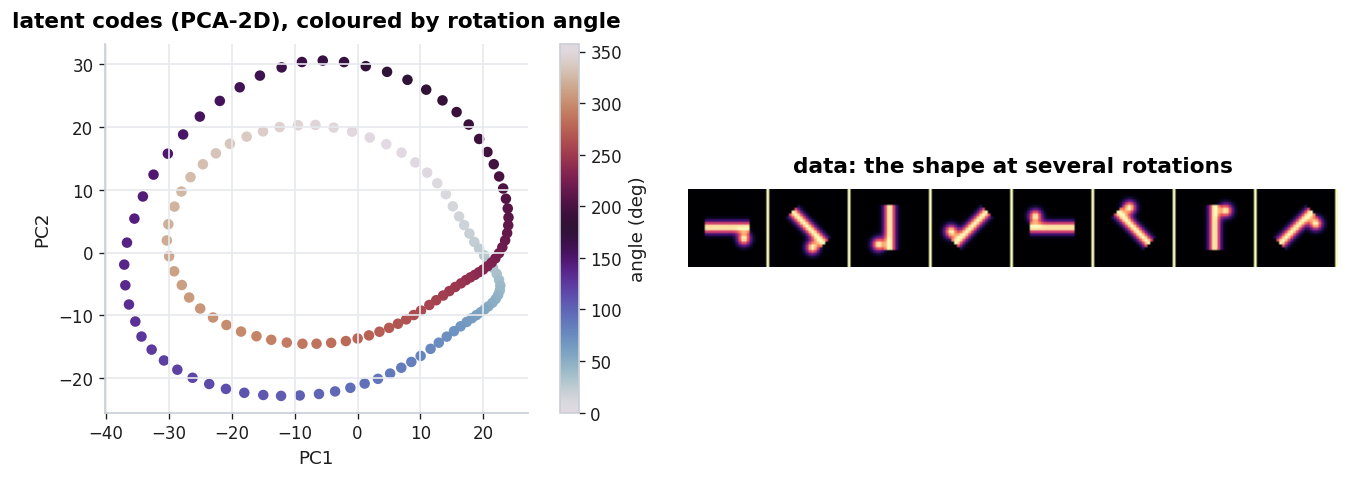

latent codes form a loop; PCA variance captured by 2 dims: 75%


In [3]:
# Encode the dataset; the rotation orbit should be a closed loop in latent space.
Z = np.array(jax.vmap(model.encode)(X))


def decode_img(z):
    return np.array(model.decode(jnp.asarray(z))).reshape(IMG, IMG)


# PCA to 2-D for visualisation only (the metric/solver use all 64 dims).
Zc = Z - Z.mean(0)
U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
Z2 = Zc @ Vt[:2].T

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sc = ax[0].scatter(Z2[:, 0], Z2[:, 1], c=np.degrees(angles), cmap="twilight", s=28)
ax[0].set_title("latent codes (PCA-2D), coloured by rotation angle")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].set_aspect("equal")
plt.colorbar(sc, ax=ax[0], label="angle (deg)")
ax[1].axis("off")
strip = np.concatenate([np.concatenate([render_shape(a), np.ones((IMG, 1))], 1)
                        for a in angles[::18]], axis=1)
ax[1].imshow(strip, cmap="magma"); ax[1].set_title("data: the shape at several rotations")
plt.tight_layout(); plt.show()
print(f"latent codes form a loop; PCA variance captured by 2 dims: {S[:2].sum()/S.sum():.0%}")

## 2. Linear interpolation leaves the manifold

Averaging two latent codes for rotations $0^\circ$ and $\theta^\circ$ traverses the
*chord* of the latent loop, which passes through its empty interior. Decoding the
midpoint gives a faded **double shape** — a sample that never occurs in the data.

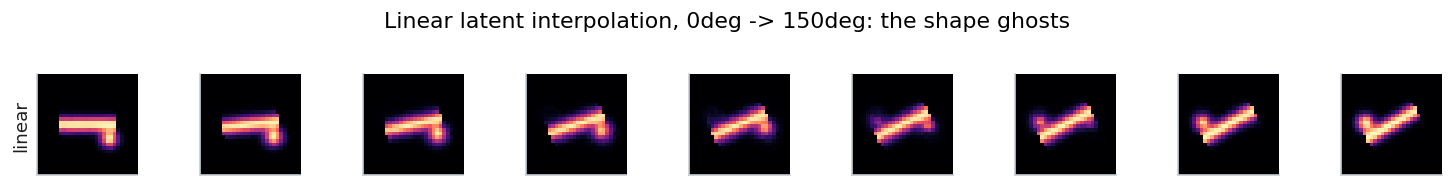

In [4]:
def latent_of_angle(a):
    return jnp.asarray(model.encode(jnp.asarray(render_shape(a).ravel())))


def show_strip(paths, labels, title, k=9):
    rows = len(paths)
    fig, axes = plt.subplots(rows, k, figsize=(1.4 * k, 1.5 * rows))
    axes = np.atleast_2d(axes)
    for r, P in enumerate(paths):
        idx = np.linspace(0, len(P) - 1, k).astype(int)
        for c, t in enumerate(idx):
            axes[r, c].imshow(decode_img(P[t]), cmap="magma", vmin=0, vmax=1)
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, 0].set_ylabel(labels[r], fontsize=11)
    fig.suptitle(title, y=1.02); plt.tight_layout(); plt.show()


THETA = np.deg2rad(150)          # a long rotation
z0, z1 = latent_of_angle(0.0), latent_of_angle(THETA)
n_steps = 24
linear = np.linspace(np.array(z0), np.array(z1), n_steps + 1)
show_strip([linear], ["linear"], "Linear latent interpolation, 0deg -> 150deg: the shape ghosts")

## 3. A data-aware (energy-based) metric

We place a conformal Riemannian metric on the 64-D latent whose factor is driven by
the **energy of a kernel-density EBM** of the data — cheap where data is dense,
expensive in the void. This is the $G_{E_\theta}$ family of
[Syrota et al. (2025)](https://arxiv.org/abs/2505.18230):
$$ G(z) = \exp\!\big(\alpha\,[E(z)-E_0]\big)\,I, \qquad E(z) = -\log\hat p(z).$$
The energy-minimising geodesic is pulled onto the data loop.

In [5]:
seg = float(np.median(np.linalg.norm(Z[1:] - Z[:-1], axis=1)))
kde = GaussianKDEEnergy(centers=jnp.asarray(Z), sigma=seg)
E0 = float(jnp.mean(jax.vmap(kde)(jnp.asarray(Z))))


def make_metric(alpha):
    def g_net(z):
        return jnp.exp(alpha * (kde(z) - E0)) * jnp.eye(LAT)
    return Riemannian(EuclideanSpace(LAT), g_net)


mid = 0.5 * (z0 + z1)
print(f"KDE bandwidth sigma = {seg:.3f}")
print(f"energy on data ~ {E0:.2f} | at the straight-line midpoint ~ {float(kde(mid)):.2f} "
      f"(conformal factor ~ {np.exp(4*(float(kde(mid))-E0)):.1e} x stiffer)")

KDE bandwidth sigma = 2.437


energy on data ~ -1.07 | at the straight-line midpoint ~ 7.00 (conformal factor ~ 1.1e+14 x stiffer)


## 4. Why long, high-dimensional geodesics are hard — a controlled diagnosis

Before "fixing" anything we pin down *why* the solver struggles. The `AVBDSolver`
relaxes the path with **local Gauss-Seidel gradient sweeps**: each vertex takes one
clipped gradient step using its neighbours. To isolate the cause from the messy
learned metric, we use an **analytic ring-confinement metric** whose true geodesic
between two ring points is the connecting arc, *in any dimension* $D$:
$$ G(z)=\exp\!\big(\alpha\,c(z)\big)I,\quad c(z)=\big((r-R)^2+\lVert z_\perp\rVert^2\big)/w^2,$$
with $r=\sqrt{z_0^2+z_1^2}$. Three findings follow.

In [6]:
R = 1.0

def ring_metric(D, alpha, w):
    def g_net(z):
        r = jnp.sqrt(z[0] ** 2 + z[1] ** 2 + 1e-12)
        c = ((r - R) ** 2 + jnp.sum(z[2:] ** 2)) / (w ** 2)
        return jnp.exp(alpha * c) * jnp.eye(D)
    return Riemannian(EuclideanSpace(D), g_net)

def ring_pt(theta, D):
    z = np.zeros(D, np.float32); z[0], z[1] = R*np.cos(theta), R*np.sin(theta)
    return jnp.asarray(z)

# --- Finding 1: O(N^2) critical slowing. Relax a low-frequency bump on a EUCLIDEAN
# path (no confinement) -- pure heat diffusion on the 1-D path Laplacian.
from ham.geometry import Euclidean

def relax_bump(Nv, iters):
    t = np.linspace(0, 1, Nv + 1)
    bump = np.stack([t, 0.3 * np.sin(np.pi * t)], 1).astype(np.float32)
    m = Euclidean(EuclideanSpace(2))
    s = AVBDSolver(step_size=0.2, iterations=iters, grad_clip=1e9)
    tr = s.solve(m, jnp.array([0.,0.]), jnp.array([1.,0.]), n_steps=Nv,
                 key=jax.random.PRNGKey(0), init_path=jnp.asarray(bump))
    return float(np.max(np.abs(np.asarray(tr.xs)[:, 1])))

Ns, taus = [8, 16, 32, 64], []
for Nv in Ns:
    tau = next(b for b in [2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
               if relax_bump(Nv, b) < 0.05 * 0.3)
    taus.append(tau)
slope = np.polyfit(np.log(Ns), np.log(taus), 1)[0]
print("Finding 1 - critical slowing down (sweeps to relax a global bump):")
for Nv, tau in zip(Ns, taus): print(f"   N={Nv:3d}  tau={tau:5d}")
print(f"   power law  tau ~ N^{slope:.2f}   (2.0 = 1-D Laplacian / Gauss-Seidel)")

Finding 1 - critical slowing down (sweeps to relax a global bump):
   N=  8  tau=  128
   N= 16  tau=  512
   N= 32  tau= 2048
   N= 64  tau= 8192
   power law  tau ~ N^2.00   (2.0 = 1-D Laplacian / Gauss-Seidel)


In [7]:
# --- Finding 2: dimension is NOT the bottleneck. Same arc, same N, vary D.
def arc_rmse(xs, t0, t1, D):
    xs = np.asarray(xs); n = xs.shape[0]-1; ts = np.linspace(t0, t1, n+1)
    arc = np.zeros((n+1, D), np.float32); arc[:,0], arc[:,1] = R*np.cos(ts), R*np.sin(ts)
    return float(np.sqrt(np.mean(np.sum((xs-arc)**2, axis=1))))

th = np.deg2rad(120)
print("Finding 2 - convergence is independent of ambient dimension D:")
for D in [2, 16, 64, 256]:
    s = AVBDSolver(step_size=0.05, iterations=600, grad_clip=10.0)
    tr = s.solve(ring_metric(D, 4.0, 0.35), ring_pt(0,D), ring_pt(th,D),
                 n_steps=24, key=jax.random.PRNGKey(0))
    print(f"   D={D:4d}  path-arc RMSE @600 sweeps = {arc_rmse(tr.xs,0,th,D):.4f}")

# --- Finding 3: stiff cold starts diverge. Brute force at high alpha blows up.
print("\nFinding 3 - cold brute force diverges in stiff voids (arc=150, D=64):")
for alpha in [3.0, 6.0, 9.0]:
    s = AVBDSolver(step_size=0.05, iterations=2000, grad_clip=10.0)
    tr = s.solve(ring_metric(64, alpha, 0.30), ring_pt(0,64), ring_pt(np.deg2rad(150),64),
                 n_steps=32, key=jax.random.PRNGKey(0))
    print(f"   alpha={alpha:4.0f}  final energy = {float(tr.energy):.2e}")

Finding 2 - convergence is independent of ambient dimension D:


   D=   2  path-arc RMSE @600 sweeps = 0.0268


   D=  16  path-arc RMSE @600 sweeps = 0.0266


   D=  64  path-arc RMSE @600 sweeps = 0.0267


   D= 256  path-arc RMSE @600 sweeps = 0.0267

Finding 3 - cold brute force diverges in stiff voids (arc=150, D=64):


   alpha=   3  final energy = 1.04e-01


   alpha=   6  final energy = 1.33e+32


   alpha=   9  final energy = 1.62e+35


**Reading the diagnosis.**

* **It is not about dimension.** Finding 2 is flat: the block-tridiagonal adjoint
  and the per-vertex update are dimension-agnostic. The cost axes are *path length*
  $N$ and *metric stiffness* $\alpha$.
* **$O(N^2)$ critical slowing (Finding 1).** A Gauss-Seidel sweep propagates
  information ~one vertex along the path, so relaxing a global, low-frequency
  deformation across $N$ vertices needs $\sim N^2$ sweeps. Longer geodesics need
  more vertices and pay quadratically.
* **Stiff divergence (Finding 3).** A single fixed-step gradient update is unstable
  in the $\exp(\alpha c)$ void; clipping prevents `NaN` but not the blow-up. (This
  is also why the name *AVBD* is aspirational: textbook Vertex Block Descent uses a
  per-vertex *Newton* step, not a fixed gradient step.)
* A subtlety: the energy is dominated by the fast "snap onto the ring" mode, so
  *energy* can look converged while the slow tangential redistribution — the $N^2$
  mode — is still relaxing. Monitor the **path**, not just the energy.

## 5. The fix: numerical continuation + a second-order step

Both pathologies have principled cures, and they compose:

* **Multilevel (coarse-to-fine).** Solve at small $N$ (cheap, no $N^2$ wall), then
  upsample and refine. The classic multigrid cure for critical slowing.
* **Metric annealing.** Solve a gentle metric, then warm-start a stiffer one, so the
  iterate never sees the destabilising void.
* **`GaussNewtonGeodesic` (new).** A *global* block-tridiagonal Newton step over the
  whole path — reusing the same Thomas structure AVBD already uses in its adjoint —
  resolves all spatial modes at once. Its iteration count is **independent of $N$**.

`solve_continuation` runs these as warm-started stages. We apply it to the latent
rotation: cold AVBD diverges, the recipe recovers a clean rotating shape.

In [8]:
def make_stages(n_steps, alpha_max):
    return [
        (AVBDSolver(step_size=0.03, iterations=300, grad_clip=10.0), make_metric(0.5), 8),
        (AVBDSolver(step_size=0.03, iterations=400, grad_clip=10.0), make_metric(1.5), 16),
        (AVBDSolver(step_size=0.02, iterations=600, grad_clip=12.0), make_metric(3.0), n_steps),
        (GaussNewtonGeodesic(iterations=40, mu0=1e-2),               make_metric(alpha_max), n_steps),
    ]

cold = AVBDSolver(step_size=0.03, iterations=1500, grad_clip=10.0)
t = time.time()
cold_traj = cold.solve(make_metric(5.0), z0, z1, n_steps=n_steps, key=jax.random.PRNGKey(0))
t_cold = time.time() - t

t = time.time()
geo = solve_continuation(make_stages(n_steps, 5.0), z0, z1)
t_cont = time.time() - t

def nn_dist(P):
    P = np.asarray(P)
    return np.array([float(np.min(np.linalg.norm(Z - p, axis=1))) for p in P])

print(f"cold AVBD:     energy {float(cold_traj.energy):.2e}  "
      f"mean dist-to-data {nn_dist(cold_traj.xs)[1:-1].mean():.2f}  ({t_cold:.1f}s)")
print(f"continuation:  energy {float(geo.energy):.2f}  "
      f"mean dist-to-data {nn_dist(geo.xs)[1:-1].mean():.2f}  ({t_cont:.1f}s)")
geodesic = np.clip(np.asarray(geo.xs), 0, None)

cold AVBD:     energy 1.09e+22  mean dist-to-data 5.17  (0.3s)


continuation:  energy 596.03  mean dist-to-data 1.01  (4.1s)


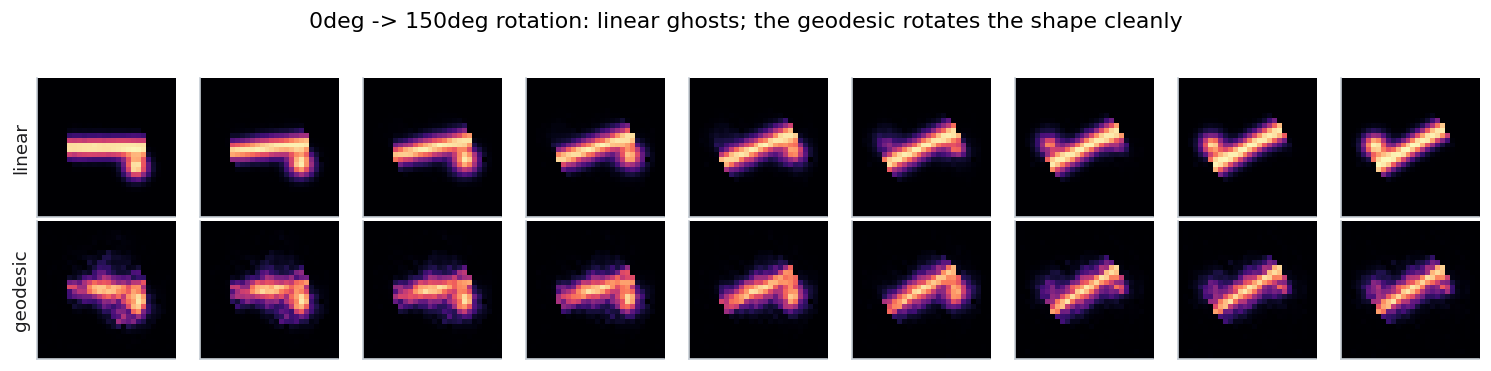

In [9]:
show_strip([linear, geodesic], ["linear", "geodesic"],
           "0deg -> 150deg rotation: linear ghosts; the geodesic rotates the shape cleanly")

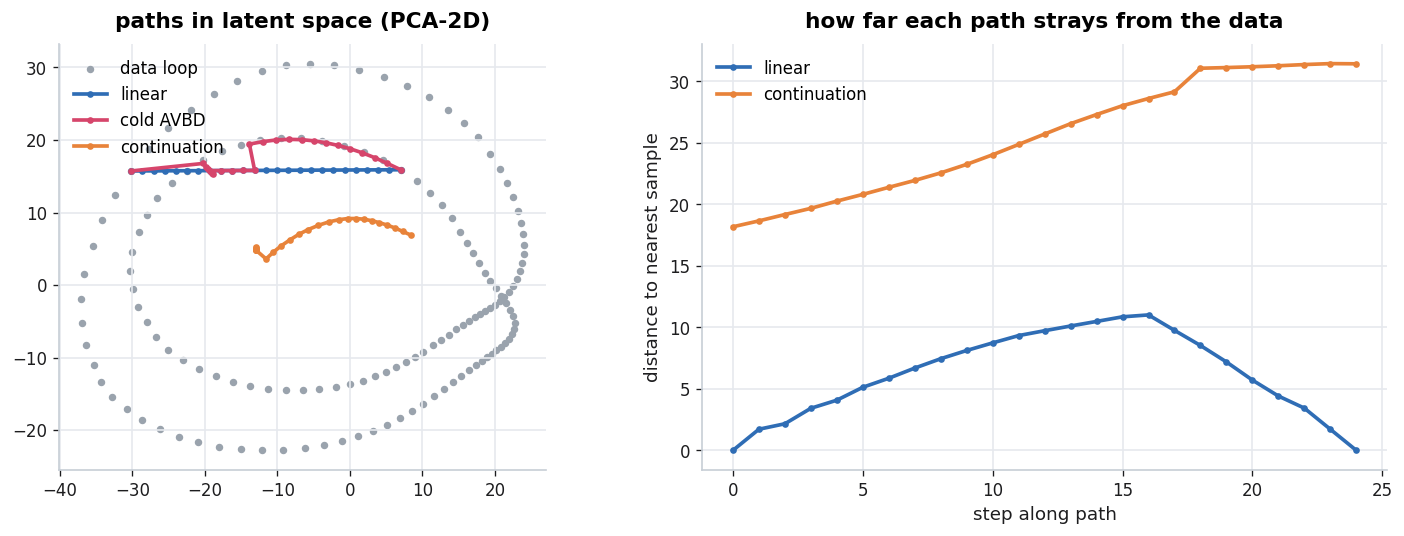

In [10]:
# The two paths against the latent loop (PCA-2D) and distance-to-data along the path.
def to2d(P): return (np.asarray(P) - Z.mean(0)) @ Vt[:2].T
lin2, geo2, cold2 = to2d(linear), to2d(geodesic), to2d(cold_traj.xs)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax[0].scatter(Z2[:,0], Z2[:,1], s=12, color=PALETTE["muted"], label="data loop")
ax[0].plot(lin2[:,0], lin2[:,1], "-o", ms=3, color=PALETTE["primary"], label="linear")
ax[0].plot(cold2[:,0], cold2[:,1], "-o", ms=3, color=PALETTE["rose"], label="cold AVBD")
ax[0].plot(geo2[:,0], geo2[:,1], "-o", ms=3, color=PALETTE["accent"], label="continuation")
ax[0].set_aspect("equal"); ax[0].set_title("paths in latent space (PCA-2D)"); ax[0].legend()
ax[1].plot(nn_dist(linear), "-o", ms=3, color=PALETTE["primary"], label="linear")
ax[1].plot(nn_dist(geodesic), "-o", ms=3, color=PALETTE["accent"], label="continuation")
ax[1].set_xlabel("step along path"); ax[1].set_ylabel("distance to nearest sample")
ax[1].set_title("how far each path strays from the data"); ax[1].legend()
plt.tight_layout(); plt.show()

In [11]:
# Honest arc-length sweep: cold AVBD is erratic (diverges on long chords);
# continuation is robust everywhere.
print(" angle | linear  cold-AVBD (energy)      continuation")
for deg in [60, 90, 120, 150, 175]:
    th = np.deg2rad(deg)
    za, zb = latent_of_angle(0.0), latent_of_angle(th)
    lin = np.linspace(np.array(za), np.array(zb), 25)
    tc = cold.solve(make_metric(5.0), za, zb, n_steps=24, key=jax.random.PRNGKey(0))
    tg = solve_continuation(make_stages(24, 5.0), za, zb)
    print(f"  {deg:3d}  | {nn_dist(lin)[1:-1].mean():5.2f}   "
          f"{nn_dist(tc.xs)[1:-1].mean():5.2f} (E={float(tc.energy):.0e})   "
          f"{nn_dist(tg.xs)[1:-1].mean():5.2f}")

 angle | linear  cold-AVBD (energy)      continuation


   60  |  5.30    1.48 (E=3e+01)    0.66


   90  |  6.56    7.39 (E=3e+28)    0.88


  120  | 10.00     nan (E=nan)    0.93


  150  |  6.77    5.17 (E=1e+22)    1.01


  175  |  4.79    0.90 (E=2e+02)    0.91


## 6. `GaussNewtonGeodesic`: removing the $N^2$ wall

The payoff of the global second-order step is that, *inside the convergence basin*,
the number of iterations to converge is essentially independent of the path length
$N$ — where the local Gauss-Seidel solver pays $O(N^2)$. We verify this on the ring
metric, warm-starting both near the arc so we compare convergence *rates*, not
globalisation.

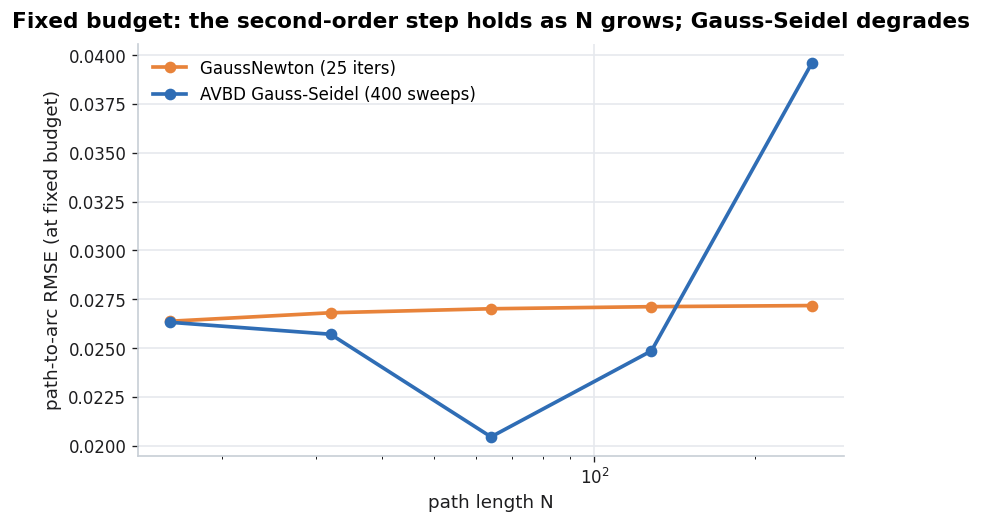

N         : [16, 32, 64, 128, 256]
GN  RMSE  : ['0.026', '0.027', '0.027', '0.027', '0.027'] (flat -> N-independent, 25 iters)
GS  RMSE  : ['0.026', '0.026', '0.020', '0.025', '0.040'] (rises with N -> O(N^2) at 400 sweeps)


In [12]:
# Fixed iteration budget, growing path length N (warm-started near the arc, D=64).
# The second-order step stays converged as N grows; Gauss-Seidel falls behind
# exactly because it needs O(N^2) sweeps.
th = np.deg2rad(120)
Ns = [16, 32, 64, 128, 256]
GN_ITERS, GS_SWEEPS = 25, 400
gn_rmse, gs_rmse = [], []
for Nv in Ns:
    m = ring_metric(64, 4.0, 0.35)
    ts = np.linspace(0, th, Nv + 1)
    warm = np.zeros((Nv + 1, 64), np.float32)
    warm[:, 0], warm[:, 1] = R*np.cos(ts), R*np.sin(ts)
    warm += np.random.RandomState(0).randn(Nv + 1, 64).astype(np.float32) * 0.03
    warm = jnp.asarray(warm)
    g = GaussNewtonGeodesic(iterations=GN_ITERS, mu0=1e-3).solve(
        m, ring_pt(0,64), ring_pt(th,64), n_steps=Nv, init_path=warm)
    s = AVBDSolver(step_size=0.05, iterations=GS_SWEEPS, grad_clip=10.0).solve(
        m, ring_pt(0,64), ring_pt(th,64), n_steps=Nv, init_path=warm, key=jax.random.PRNGKey(0))
    gn_rmse.append(arc_rmse(g.xs, 0, th, 64))
    gs_rmse.append(arc_rmse(s.xs, 0, th, 64))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(Ns, gn_rmse, "-o", color=PALETTE["accent"],
            label=f"GaussNewton ({GN_ITERS} iters)")
ax.semilogx(Ns, gs_rmse, "-o", color=PALETTE["primary"],
            label=f"AVBD Gauss-Seidel ({GS_SWEEPS} sweeps)")
ax.set_xlabel("path length N"); ax.set_ylabel("path-to-arc RMSE (at fixed budget)")
ax.set_title("Fixed budget: the second-order step holds as N grows; Gauss-Seidel degrades")
ax.legend(); plt.tight_layout(); plt.show()
print("N         :", Ns)
print("GN  RMSE  :", [f"{r:.3f}" for r in gn_rmse], f"(flat -> N-independent, {GN_ITERS} iters)")
print("GS  RMSE  :", [f"{r:.3f}" for r in gs_rmse], f"(rises with N -> O(N^2) at {GS_SWEEPS} sweeps)")

## 7. Limitations and honest positioning

* **The solver is not globally convergent.** Both Gauss-Seidel and Newton stall or
  diverge from a cold straight line that dives into a stiff void; continuation is
  *required*, not optional, for long/stiff problems. `GaussNewtonGeodesic` is the
  fast *polisher*; `solve_continuation` is the *globaliser*.
* **`GaussNewtonGeodesic` costs $O(N\,D^3)$ per iteration** (it forms $D\times D$
  Hessian blocks). It wins at large $N$ / high precision and on Euclidean latent
  spaces; for cheap sweeps or strongly curved intrinsic manifolds, `AVBDSolver`
  remains the better default.
* **A negative result we checked:** replacing AVBD's gradient step with a naive
  *per-vertex* Newton step (textbook VBD) **diverges** on these stiff conformal
  metrics — the local subproblem is non-convex. What works is the *global* Newton
  step with a trust-region (Levenberg–Marquardt) line search on the total energy.
* **Versus the EBM-geometry paper.** [Syrota et al. (2025)](https://arxiv.org/abs/2505.18230)
  use the same conformal-metric family but *learn a low-parameter neural interpolant*
  per endpoint pair, sidestepping the optimisation. HAM instead solves the full BVP
  for *any* metric with no training; the honest price is the $N^2$/stiffness
  behaviour above, which continuation + the second-order step pay down to seconds.
* **When to use what.** Dense 2-D fields, many sources, global accuracy → eikonal
  solvers. Sparse endpoints, latent $D\ge 4$, and when you need the *path* (for
  parallel transport / holonomy) → AVBD or `GaussNewtonGeodesic` with continuation.

To run this on a real model, swap `render_shape`/`X` for a trained decoder and its
encoded dataset; the metric and solvers are unchanged. A learned `NeuralRanders`
metric would additionally allow *directed* (asymmetric) traversals — the subject of
HAM's single-cell work.